In [1]:
# ============================================================
#  CELL 1 — IMPORTS & CONFIGURATION
# ============================================================
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torchvision.models as models #new
from PIL import Image
from sklearn.metrics import mean_absolute_error


warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED);  np.random.seed(SEED)
torch.manual_seed(SEED);  torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Exact paths from dataset screenshot ──────────────────────
BASE_DIR      = Path("/kaggle/input/datasets/ipythonx/rsna-bone-age")
# Image folders
TRAIN_IMG_DIR = BASE_DIR / "RSNA_train" / "images"
VAL_IMG_DIR   = BASE_DIR / "RSNA_val"   / "images"
TEST_IMG_DIR  = BASE_DIR / "RSNA_test"  / "images"

# Annotation CSVs  (RSNA_Annotations/RSNA_Annotations/BONEAGE/)
BONEAGE_DIR   = BASE_DIR / "RSNA_Annotations" / "RSNA_Annotations" / "BONEAGE"
TRAIN_CSV     = BONEAGE_DIR / "boneage_train.csv"
VAL_CSV       = BONEAGE_DIR / "boneage_val.csv"
TEST_CSV      = BONEAGE_DIR / "gender_test.csv"   # test CSV has no bone_age label

# ROI JSONs (available for future use)
ROI_DIR       = BASE_DIR / "RSNA_Annotations" / "RSNA_Annotations" / "ANATOMICAL_ROIS"
ROI_TRAIN     = ROI_DIR / "anatomical_ROIs_train.json"
ROI_VAL       = ROI_DIR / "anatomical_ROIs_val.json"
ROI_TEST      = ROI_DIR / "anatomical_ROIs_test.json"

# ── Verify all paths exist ────────────────────────────────────
paths_to_check = {
    "TRAIN_IMG_DIR" : TRAIN_IMG_DIR,
    "VAL_IMG_DIR"   : VAL_IMG_DIR,
    "TEST_IMG_DIR"  : TEST_IMG_DIR,
    "TRAIN_CSV"     : TRAIN_CSV,
    "VAL_CSV"       : VAL_CSV,
    "TEST_CSV"      : TEST_CSV,
}
print("\nPath verification:")
all_ok = True
for name, path in paths_to_check.items():
    ok = path.exists()
    status = "OK" if ok else "MISSING"
    print(f"  [{status}]  {name:15s}  {path}")
    if not ok:
        all_ok = False

if all_ok:
    print("\nAll paths verified.")
else:
    print("\nWARNING: some paths are missing — check the dataset mount.")

# ── Hyperparameters ───────────────────────────────────────────
IMG_SIZE     = 256
BATCH_SIZE   = 32
NUM_EPOCHS   = 50
LR           = 1e-3
LR_PATIENCE  = 5
ES_PATIENCE  = 10
DROPOUT      = 0.3
MAX_AGE      = 216.0    # months  (0–18 yrs)
NUM_BINS     = 18

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"\nHyperparameters set. IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE} | LR={LR}")

Device : cuda
GPU    : Tesla T4

Path verification:
  [OK]  TRAIN_IMG_DIR    /kaggle/input/datasets/ipythonx/rsna-bone-age/RSNA_train/images
  [OK]  VAL_IMG_DIR      /kaggle/input/datasets/ipythonx/rsna-bone-age/RSNA_val/images
  [OK]  TEST_IMG_DIR     /kaggle/input/datasets/ipythonx/rsna-bone-age/RSNA_test/images
  [OK]  TRAIN_CSV        /kaggle/input/datasets/ipythonx/rsna-bone-age/RSNA_Annotations/RSNA_Annotations/BONEAGE/boneage_train.csv
  [OK]  VAL_CSV          /kaggle/input/datasets/ipythonx/rsna-bone-age/RSNA_Annotations/RSNA_Annotations/BONEAGE/boneage_val.csv
  [OK]  TEST_CSV         /kaggle/input/datasets/ipythonx/rsna-bone-age/RSNA_Annotations/RSNA_Annotations/BONEAGE/gender_test.csv

All paths verified.

Hyperparameters set. IMG_SIZE=256 | BATCH=32 | LR=0.001


In [2]:
# ============================================================
#  CELL 2 — DATA PIPELINE
#  Reads the exact CSVs shown in the screenshot:
#    boneage_train.csv  →  has: image id, bone_age, sex
#    boneage_val.csv    →  has: image id, bone_age, sex
#    gender_test.csv    →  has: image id, sex  (no bone_age)
# ============================================================

# ── 2.1  Preview raw CSVs so we see exact column names ────────
print("=" * 55)
for label, path in [("TRAIN", TRAIN_CSV), ("VAL", VAL_CSV), ("TEST", TEST_CSV)]:
    df_peek = pd.read_csv(path)
    print(f"\n{label} CSV  ({path.name})  —  shape: {df_peek.shape}")
    print(f"  Columns : {df_peek.columns.tolist()}")
    print(df_peek.head(3).to_string(index=False))
print("=" * 55)


# ── 2.2  Generic loader ───────────────────────────────────────
def load_df(csv_path, img_dir, has_label=True):
    """
    Load a split CSV, normalise column names to:
        id | bone_age | sex | path | bone_age_scaled | age_bin
    For the test split (has_label=False) bone_age columns are skipped.
    """
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    # ── Map whatever column names exist → standard names ─────
    col_map = {}
    for col in df.columns:
        c = col.lower()
        if c in ("id", "image_id", "imageid", "case id", "case_id"):
            col_map[col] = "id"
        elif c in ("boneage", "bone_age", "age", "bone age"):
            col_map[col] = "bone_age"
        elif c in ("male", "gender", "sex", "male (1=male)"):
            col_map[col] = "sex"
    df = df.rename(columns=col_map)

    # ── Normalise sex to int 1/0 ─────────────────────────────
    if "sex" in df.columns:
        if df["sex"].dtype == object:
            df["sex"] = (
                df["sex"].str.strip().str.lower()
                .map({"male": 1, "female": 0, "m": 1, "f": 0,
                      "true": 1, "false": 0, "1": 1, "0": 0})
                .fillna(0).astype(int)
            )
        else:
            # boolean True/False or 1.0/0.0
            df["sex"] = df["sex"].fillna(0).astype(int)
    else:
        print(f"  WARNING: no sex column found in {csv_path.name}, defaulting to 0.")
        df["sex"] = 0

    # ── Resolve image paths (.png preferred, .jpg fallback) ──
    def resolve(img_id):
        for ext in (".png", ".PNG", ".jpg", ".jpeg"):
            p = img_dir / f"{img_id}{ext}"
            if p.exists():
                return p
        return None

    df["path"] = df["id"].apply(resolve)
    missing = df["path"].isna().sum()
    if missing:
        print(f"  WARNING: {missing} images not found for {csv_path.name}, dropping.")
    df = df.dropna(subset=["path"]).reset_index(drop=True)

    # ── Label columns (train / val only) ─────────────────────
    if has_label and "bone_age" in df.columns:
        df["bone_age"]        = pd.to_numeric(df["bone_age"], errors="coerce")
        df                    = df.dropna(subset=["bone_age"]).reset_index(drop=True)
        df["bone_age_scaled"] = df["bone_age"] / MAX_AGE
        df["age_bin"]         = pd.cut(df["bone_age"], bins=NUM_BINS, labels=False)
    elif has_label:
        raise ValueError(
            f"Expected a bone_age column in {csv_path.name} "
            f"but found: {df.columns.tolist()}"
        )

    return df


# ── 2.3  Load all three splits ────────────────────────────────
train_df = load_df(TRAIN_CSV, TRAIN_IMG_DIR, has_label=True)
val_df   = load_df(VAL_CSV,   VAL_IMG_DIR,   has_label=True)
test_df  = load_df(TEST_CSV,  TEST_IMG_DIR,  has_label=False)

print("\nLoaded splits:")
print(f"  Train : {len(train_df):>5} samples | "
      f"age {train_df['bone_age'].min():.0f}–{train_df['bone_age'].max():.0f} mo | "
      f"male {(train_df['sex']==1).sum()} / female {(train_df['sex']==0).sum()}")
print(f"  Val   : {len(val_df):>5} samples | "
      f"age {val_df['bone_age'].min():.0f}–{val_df['bone_age'].max():.0f} mo | "
      f"male {(val_df['sex']==1).sum()} / female {(val_df['sex']==0).sum()}")
print(f"  Test  : {len(test_df):>5} samples | "
      f"no bone_age labels (gender_test.csv) | "
      f"male {(test_df['sex']==1).sum()} / female {(test_df['sex']==0).sum()}")

print("\nTrain sample:")
print(train_df[["id", "bone_age", "sex", "bone_age_scaled", "age_bin"]].head(3))


# ── 2.4  Transforms ──────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


# ── 2.5  Dataset class ────────────────────────────────────────
class BoneAgeDataset(Dataset):
    """
    For train/val:  returns (img_tensor, sex_float, bone_age_scaled)
    For test:       returns (img_tensor, sex_float, -1.0)  ← no label
    """
    def __init__(self, dataframe, transform=None, has_label=True):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.has_label = has_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("L")
        if self.transform:
            img = self.transform(img)
        sex   = torch.tensor(float(row["sex"]), dtype=torch.float32)
        label = torch.tensor(
            float(row["bone_age_scaled"]) if self.has_label else -1.0,
            dtype=torch.float32
        )
        return img, sex, label


# ── 2.6  Weighted sampler (training imbalance) ────────────────
bin_counts  = train_df["age_bin"].value_counts().sort_index()
bin_weights = 1.0 / bin_counts
sample_w    = train_df["age_bin"].map(bin_weights).values
sampler     = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_w),
    num_samples = len(train_df),
    replacement = True,
)


# ── 2.7  DataLoaders ─────────────────────────────────────────
train_ds = BoneAgeDataset(train_df, transform=train_transforms, has_label=True)
val_ds   = BoneAgeDataset(val_df,   transform=eval_transforms,  has_label=True)
test_ds  = BoneAgeDataset(test_df,  transform=eval_transforms,  has_label=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\nDataLoaders ready:")
print(f"  train  {len(train_loader)} batches")
print(f"  val    {len(val_loader)} batches")
print(f"  test   {len(test_loader)} batches  (no labels — inference only)")


TRAIN CSV  (boneage_train.csv)  —  shape: (12611, 3)
  Columns : ['ID', 'Male', 'Boneage']
  ID  Male  Boneage
1377 False      180
1378 False       12
1379 False       94

VAL CSV  (boneage_val.csv)  —  shape: (1425, 3)
  Columns : ['ID', 'Male', 'Boneage']
  ID  Male  Boneage
1386 False       30
1392  True      162
1397 False       18

TEST CSV  (gender_test.csv)  —  shape: (200, 2)
  Columns : ['ID', 'Male']
  ID  Male
4360  True
4361  True
4362  True

Loaded splits:
  Train : 12611 samples | age 1–228 mo | male 6833 / female 5778
  Val   :  1425 samples | age 3–228 mo | male 773 / female 652
  Test  :   200 samples | no bone_age labels (gender_test.csv) | male 100 / female 100

Train sample:
     id  bone_age  sex  bone_age_scaled  age_bin
0  1377       180    0         0.833333       14
1  1378        12    0         0.055556        0
2  1379        94    0         0.435185        7

DataLoaders ready:
  train  395 batches
  val    45 batches
  test   7 batches  (no labels — infer

In [3]:
for name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("\n", name.upper())
    print(df_.columns.tolist())


 TRAIN
['id', 'sex', 'bone_age', 'path', 'bone_age_scaled', 'age_bin']

 VAL
['id', 'sex', 'bone_age', 'path', 'bone_age_scaled', 'age_bin']

 TEST
['id', 'sex', 'path']


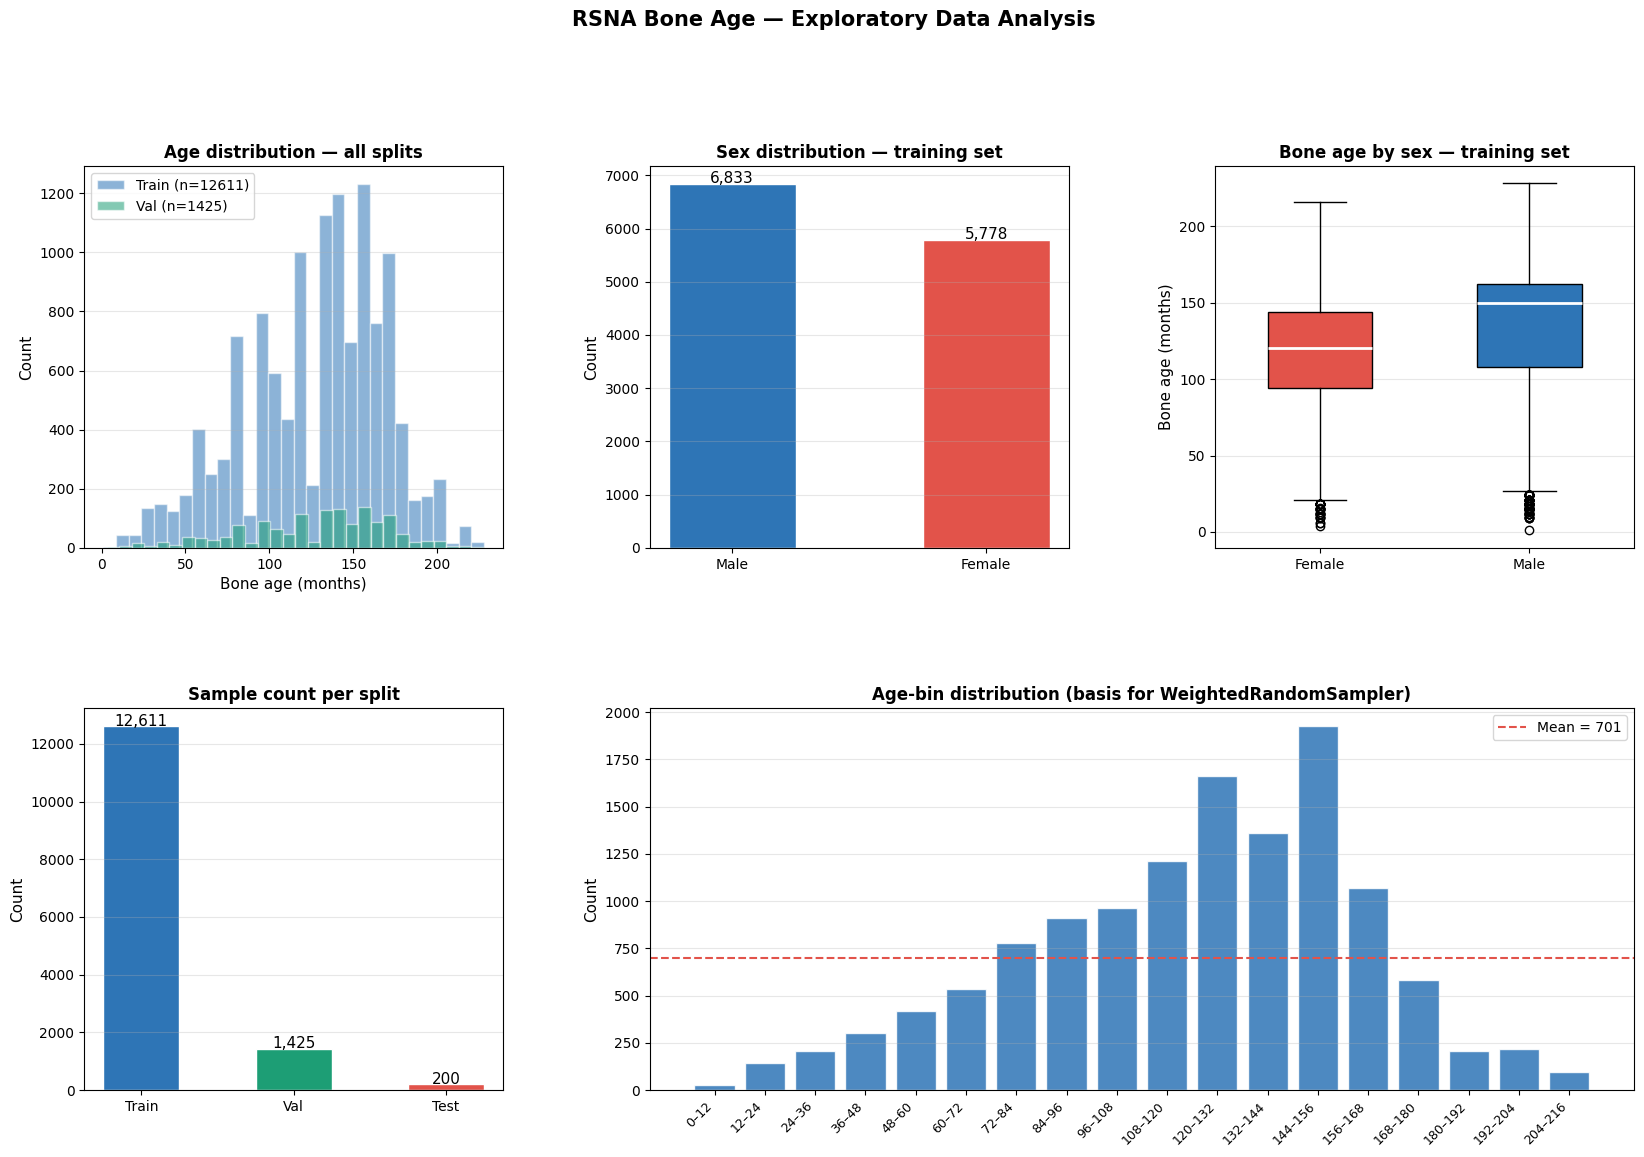

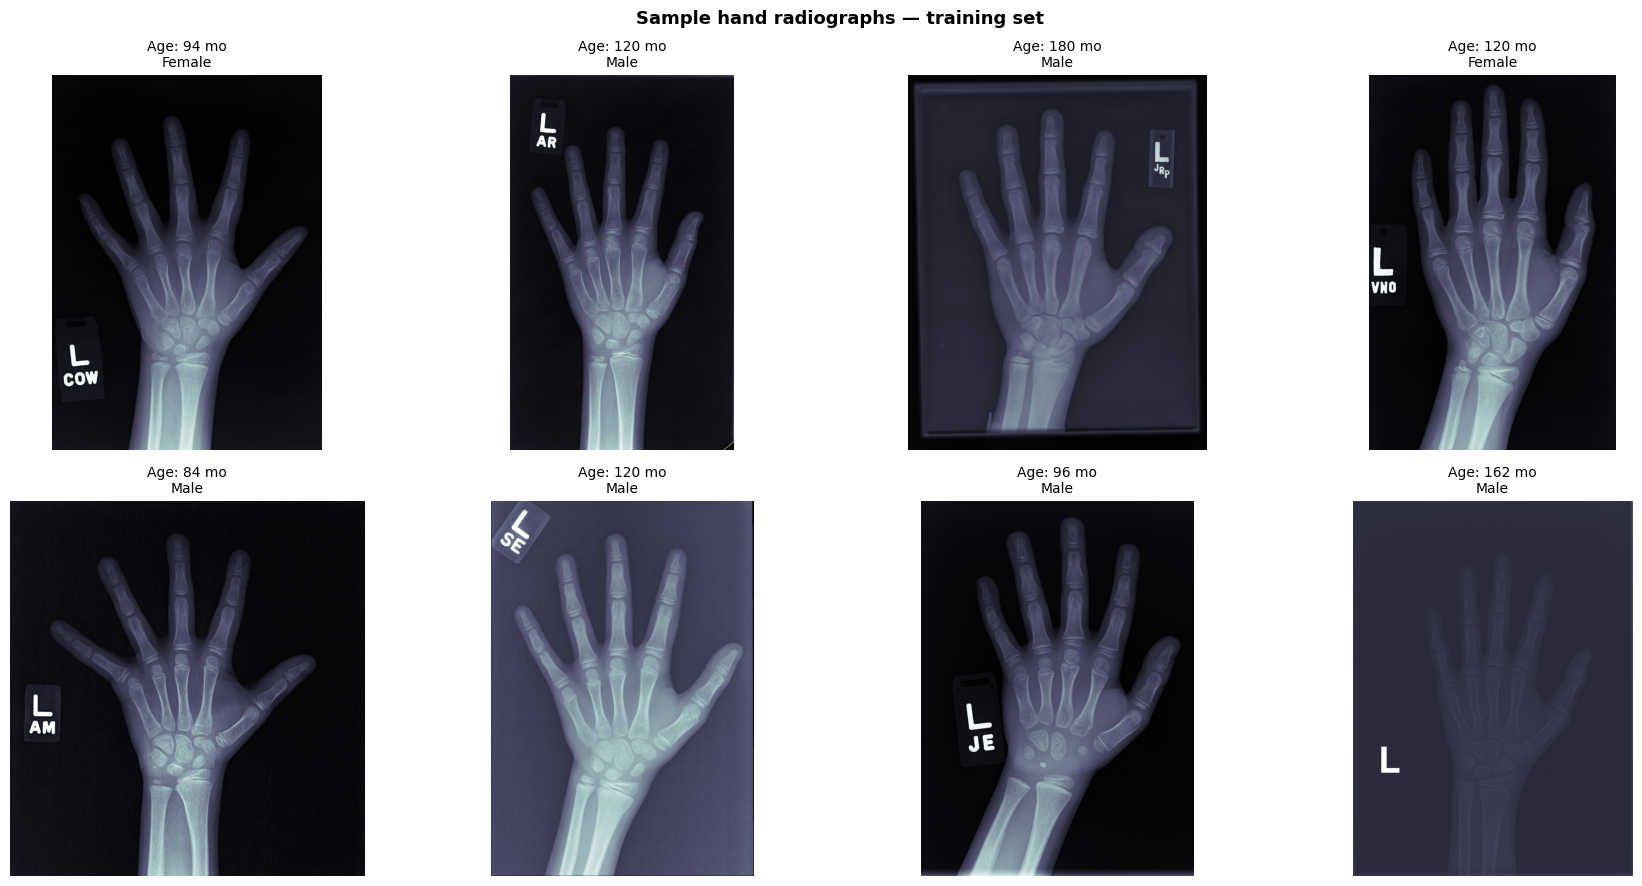

Training set statistics:
count    12611.00
mean       127.32
std         41.18
min          1.00
25%         96.00
50%        132.00
75%        156.00
max        228.00
Name: bone_age, dtype: float64

Male   : 6833 samples
Female : 5778 samples


In [4]:
# ============================================================
#  CELL 3 — EXPLORATORY DATA ANALYSIS
# ============================================================

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
train_df = train_df.rename(columns={"boneage": "bone_age", "male": "sex"})
val_df   = val_df.rename(columns={"boneage": "bone_age", "male": "sex"})
test_df  = test_df.rename(columns={"boneage": "bone_age", "male": "sex"})
# ── Age distribution per split ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for df_, label, color in [
    (train_df, "Train", "#2E75B6"),
    (val_df,   "Val",   "#1D9E75"),
    (test_df,  "Test",  "#E2534A"),
]:
    if "bone_age" in df_.columns:
        ax1.hist(df_["bone_age"], bins=30, alpha=0.55,
                 label=f"{label} (n={len(df_)})",
                 color=color, edgecolor="white")
ax1.set_xlabel("Bone age (months)", fontsize=11)
ax1.set_ylabel("Count", fontsize=11)
ax1.set_title("Age distribution — all splits", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10);  ax1.grid(axis="y", alpha=0.3)

# ── Sex distribution ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sex_counts = train_df["sex"].map({1: "Male", 0: "Female"}).value_counts()
ax2.bar(sex_counts.index, sex_counts.values,
        color=["#2E75B6", "#E2534A"], edgecolor="white", width=0.5)
for i, (_, v) in enumerate(sex_counts.items()):
    ax2.text(i, v + 30, f"{v:,}", ha="center", fontsize=11)
ax2.set_title("Sex distribution — training set", fontsize=12, fontweight="bold")
ax2.set_ylabel("Count", fontsize=11);  ax2.grid(axis="y", alpha=0.3)

# ── Boxplot age by sex ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bp = ax3.boxplot(
    [train_df[train_df["sex"]==0]["bone_age"],
     train_df[train_df["sex"]==1]["bone_age"]],
    labels=["Female", "Male"], patch_artist=True,
    medianprops=dict(color="white", linewidth=2), widths=0.5
)
bp["boxes"][0].set_facecolor("#E2534A")
bp["boxes"][1].set_facecolor("#2E75B6")
ax3.set_title("Bone age by sex — training set", fontsize=12, fontweight="bold")
ax3.set_ylabel("Bone age (months)", fontsize=11);  ax3.grid(axis="y", alpha=0.3)

# ── Split sizes ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
splits = ["Train", "Val", "Test"]
sizes  = [len(train_df), len(val_df), len(test_df)]
colors = ["#2E75B6", "#1D9E75", "#E2534A"]
bars   = ax4.bar(splits, sizes, color=colors, edgecolor="white", width=0.5)
for b in bars:
    ax4.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
             f"{b.get_height():,}", ha="center", fontsize=11)
ax4.set_title("Sample count per split", fontsize=12, fontweight="bold")
ax4.set_ylabel("Count", fontsize=11);  ax4.grid(axis="y", alpha=0.3)

# ── Age-bin frequency (imbalance) ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
bin_freq   = train_df["age_bin"].value_counts().sort_index()
bin_labels = [f"{int(i*12)}–{int((i+1)*12)}" for i in range(NUM_BINS)]
ax5.bar(range(len(bin_freq)), bin_freq.values,
        color="#2E75B6", edgecolor="white", alpha=0.85)
ax5.set_xticks(range(NUM_BINS))
ax5.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=9)
ax5.axhline(bin_freq.mean(), color="#E2534A", lw=1.5, linestyle="--",
            label=f"Mean = {bin_freq.mean():.0f}")
ax5.set_title("Age-bin distribution (basis for WeightedRandomSampler)",
              fontsize=12, fontweight="bold")
ax5.set_ylabel("Count", fontsize=11)
ax5.legend(fontsize=10);  ax5.grid(axis="y", alpha=0.3)

plt.suptitle("RSNA Bone Age — Exploratory Data Analysis",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Sample image grid ─────────────────────────────────────────
sample_rows = train_df.sample(8, random_state=SEED)
fig2, axes  = plt.subplots(2, 4, figsize=(18, 9))
for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    ax.imshow(Image.open(row["path"]).convert("L"), cmap="bone")
    ax.set_title(
        f"Age: {row['bone_age']} mo\n"
        f"{'Male' if row['sex']==1 else 'Female'}",
        fontsize=10
    )
    ax.axis("off")
plt.suptitle("Sample hand radiographs — training set",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Descriptor stats ─────────────────────────────────────────
print("Training set statistics:")
print(train_df["bone_age"].describe().round(2))
print(f"\nMale   : {(train_df['sex']==1).sum()} samples")
print(f"Female : {(train_df['sex']==0).sum()} samples")

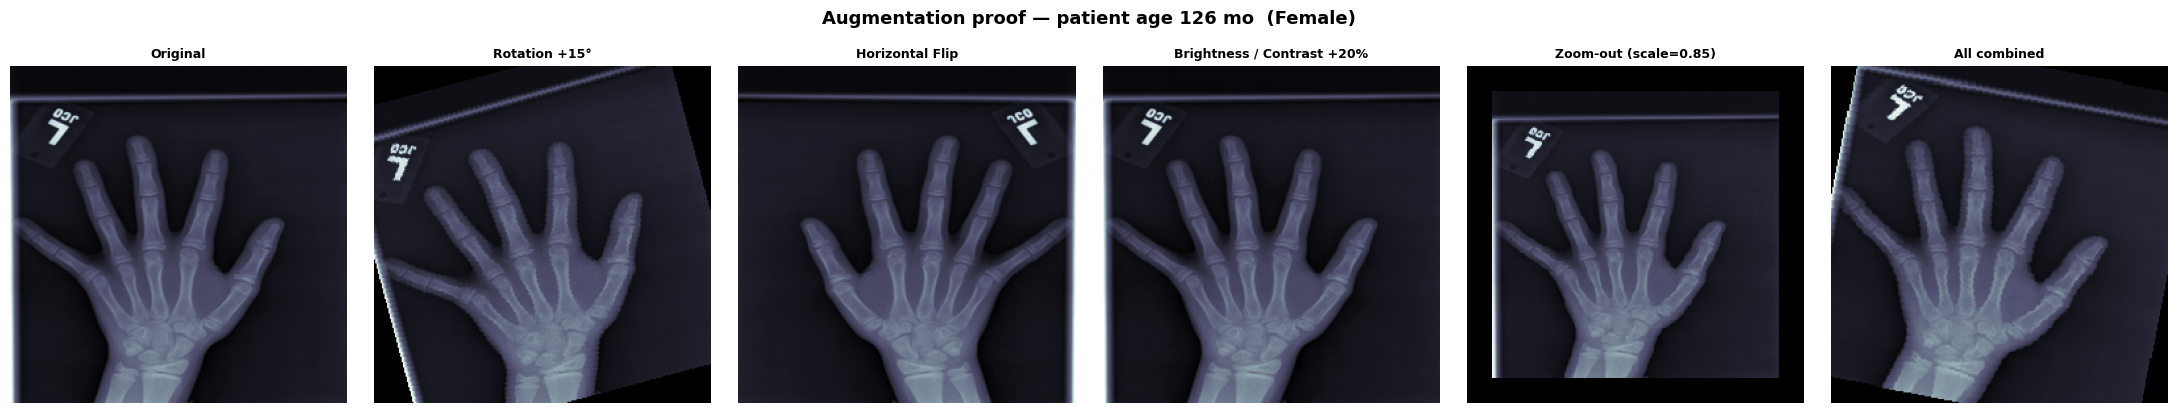

Augmentation visualisation saved → augmentation_proof.png


In [5]:
# ============================================================
#  CELL 3b — AUGMENTATION VISUALISATION  (Data Pipeline Proof)
#  Shows original X-ray vs 5 augmented versions side-by-side
# ============================================================

# Pick one representative image from training set
sample_row = train_df.iloc[10]
orig_img   = Image.open(sample_row["path"]).convert("L")

# ── Define each augmentation WITH ToTensor at the end ────────
aug_pipeline = [
    ("Original", transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(3),
        transforms.ToTensor(),
    ])),
    ("Rotation +15°", transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(3),
        transforms.RandomRotation((15, 15)),
        transforms.ToTensor(),
    ])),
    ("Horizontal Flip", transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(3),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
    ])),
    ("Brightness / Contrast +20%", transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ])),
    ("Zoom-out (scale=0.85)", transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(3),
        transforms.RandomAffine(degrees=0, scale=(0.85, 0.85)),
        transforms.ToTensor(),
    ])),
    ("All combined", transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),   # ← 1-channel normalize
])),
]

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
fig.suptitle(
    f"Augmentation proof — patient age {sample_row['bone_age']:.0f} mo  "
    f"({'Male' if sample_row['sex'] == 1 else 'Female'})",
    fontsize=13, fontweight="bold", y=1.02
)

for ax, (title, tfm) in zip(axes, aug_pipeline):
    t   = tfm(orig_img)                          # now always a tensor (C,H,W)
    arr = t.numpy().transpose(1, 2, 0)           # → (H,W,C)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    ax.imshow(arr[:, :, 0], cmap="bone")         # single channel
    ax.set_title(title, fontsize=9, fontweight="bold", wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.savefig("augmentation_proof.png", dpi=150, bbox_inches="tight")
plt.show()
print("Augmentation visualisation saved → augmentation_proof.png")

In [6]:
# ============================================================
#  CELL 4 — IMPROVED MODEL ARCHITECTURE
#  Backbone : EfficientNet-B3 (pretrained ImageNet weights)
#  Sex input: separate 2-layer MLP branch
#  Head     : Linear(1552→512) → ReLU → Dropout → Linear(512→1)
# ============================================================


torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32        = True

class BoneAgeModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(BoneAgeModel, self).__init__()

        # --- Backbone: EfficientNet-B3 pretrained ---
        efficientnet = models.efficientnet_b3(weights='IMAGENET1K_V1')

        # Adapt first conv layer for grayscale (1 channel instead of 3)
        original_conv = efficientnet.features[0][0]
        efficientnet.features[0][0] = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False
        )
        # Initialise new conv by averaging pretrained RGB weights across channels
        with torch.no_grad():
            efficientnet.features[0][0].weight = nn.Parameter(
                original_conv.weight.mean(dim=1, keepdim=True)
            )

        # Strip the classifier, keep only the feature extractor
        self.backbone = efficientnet.features
        self.pool     = nn.AdaptiveAvgPool2d(1)   # → (batch, 1536, 1, 1)

        # --- Sex sub-branch: small MLP ---
        self.sex_branch = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU()
        )

        # --- Regression head ---
        # EfficientNet-B3 outputs 1536 features + 16 from sex branch = 1552
        self.head = nn.Sequential(
            nn.Linear(1536 + 16, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 1)
        )

        # Flag to control freezing
        self.backbone_frozen = False

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.backbone_frozen = True
        print("Backbone frozen — training head only")

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        self.backbone_frozen = False
        print("Backbone unfrozen — full fine-tuning")

    def forward(self, image, sex):
        # Image path
        x = self.backbone(image)
        x = self.pool(x)
        x = x.view(x.size(0), -1)          # (batch, 1536)

        # Sex path
        s = sex.view(-1, 1).float()         # (batch, 1)
        s = self.sex_branch(s)              # (batch, 16)

        # Merge and predict
        x = torch.cat([x, s], dim=1)       # (batch, 1552)
        return self.head(x).squeeze(1)


# ── Instantiate ───────────────────────────────────────────────
model = BoneAgeModel(dropout_rate=0.3).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 55)
print("  BoneAgeModel — EfficientNet-B3 + Sex MLP Branch")
print("=" * 55)
print(f"  Backbone  : EfficientNet-B3 (pretrained ImageNet)")
print(f"  Input     : Grayscale (1 channel, averaged from RGB weights)")
print(f"  Sex branch: Linear(1→16) → ReLU → Linear(16→16) → ReLU")
print(f"  Head      : Linear(1552→512) → ReLU → Dropout(0.3) → Linear(512→1)")
print(f"  Device    : {DEVICE}")
print("-" * 55)
print(f"  Total params     : {total_p:,}")
print(f"  Trainable params : {trainable_p:,}")
print("=" * 55)

# ── Shape sanity check ────────────────────────────────────────
try:
    dummy_img = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_sex = torch.zeros(2).to(DEVICE)
    with torch.no_grad():
        out = model(dummy_img, dummy_sex)
    print(f"\nForward pass OK  →  output shape: {tuple(out.shape)}")
except Exception as e:
    print(f"\nForward pass failed: {e}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 186MB/s] 


  BoneAgeModel — EfficientNet-B3 + Sex MLP Branch
  Backbone  : EfficientNet-B3 (pretrained ImageNet)
  Input     : Grayscale (1 channel, averaged from RGB weights)
  Sex branch: Linear(1→16) → ReLU → Linear(16→16) → ReLU
  Head      : Linear(1552→512) → ReLU → Dropout(0.3) → Linear(512→1)
  Device    : cuda
-------------------------------------------------------
  Total params     : 11,491,465
  Trainable params : 11,491,465

Forward pass OK  →  output shape: (2,)


In [7]:
# ============================================================
#  CELL 5 — IMPROVED TRAINING LOOP
#  Loss      : HuberLoss (robust to outlier ages)
#  Optimizer : AdamW (weight_decay=1e-4)
#  Scheduler : ReduceLROnPlateau on val MAE
#  Extras    : Gradient clipping, Early stopping
#  Strategy  : Freeze backbone for 5 epochs → full fine-tune
# ============================================================

criterion = nn.HuberLoss()

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    factor   = 0.5,
    patience = LR_PATIENCE,
)

# ── Training utilities ────────────────────────────────────────
def run_epoch(loader, train=True):
    """One full pass. Returns (avg_huber_loss, mae_in_months)."""
    model.train() if train else model.eval()
    total_loss = total_mae = n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, sexes, labels in loader:
            imgs   = imgs.to(DEVICE,   non_blocking=True)
            sexes  = sexes.to(DEVICE,  non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            preds = model(imgs, sexes)
            loss  = criterion(preds, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping — prevents loss spikes
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            bs          = imgs.size(0)
            total_loss += loss.item() * bs
            total_mae  += (preds - labels).abs().mean().item() * MAX_AGE * bs
            n           += bs

    return total_loss / n, total_mae / n


# ── Two-stage training ────────────────────────────────────────
# Stage 1: freeze backbone, train head only for 5 epochs
# Stage 2: unfreeze everything, fine-tune end-to-end

FREEZE_EPOCHS = 5   # how long to train head-only before unfreezing

history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
best_val_mae = float("inf")
best_weights = None
es_counter   = 0

print(f"{'Ep':>4} | {'Stage':>10} | {'LR':>8} | {'Tr Loss':>9} | "
      f"{'Vl Loss':>9} | {'Tr MAE':>9} | {'Vl MAE':>9}")
print("-" * 72)

# Freeze backbone for Stage 1
model.freeze_backbone()

for epoch in range(1, NUM_EPOCHS + 1):

    # Switch to Stage 2 after FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS + 1:
        model.unfreeze_backbone()
        # Lower LR for full fine-tuning
        for pg in optimizer.param_groups:
            pg['lr'] = 1e-4
        print(f"  LR reset to 1e-4 for full fine-tuning")
        print("-" * 72)

    stage = "head-only" if model.backbone_frozen else "full ft"

    tr_loss, tr_mae = run_epoch(train_loader, train=True)
    vl_loss, vl_mae = run_epoch(val_loader,   train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_mae"].append(tr_mae)
    history["val_mae"].append(vl_mae)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"{epoch:>4} | {stage:>10} | {current_lr:>8.2e} | "
          f"{tr_loss:>9.5f} | {vl_loss:>9.5f} | "
          f"{tr_mae:>7.2f} mo | {vl_mae:>7.2f} mo")

    # Step scheduler on val MAE
    scheduler.step(vl_mae)

    # Save best weights
    if vl_mae < best_val_mae:
        best_val_mae = vl_mae
        best_weights = {k: v.cpu().clone()
                        for k, v in model.state_dict().items()}
        torch.save(best_weights, "/kaggle/working/best_bone_age_model.pth")
        print(f"       * New best  (val MAE = {best_val_mae:.2f} mo)")
        es_counter = 0
    else:
        es_counter += 1

    # Save checkpoint every 5 epochs to resume if interrupted
    if epoch % 5 == 0:
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
            'best_val_mae'    : best_val_mae,
            'history'         : history,
        }, f"/kaggle/working/checkpoint_ep{epoch}.pth")
        print(f"       ~ Checkpoint saved (ep {epoch})")

    # Early stopping
    if es_counter >= ES_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} "
              f"(no improvement for {ES_PATIENCE} epochs)")
        break

model.load_state_dict(best_weights)
print(f"\nTraining done.  Best val MAE : {best_val_mae:.2f} months")

  Ep |      Stage |       LR |   Tr Loss |   Vl Loss |    Tr MAE |    Vl MAE
------------------------------------------------------------------------
Backbone frozen — training head only
   1 |  head-only | 1.00e-03 |   0.01803 |   0.00874 |   30.90 mo |   22.18 mo
       * New best  (val MAE = 22.18 mo)
   2 |  head-only | 1.00e-03 |   0.01261 |   0.00862 |   26.72 mo |   21.84 mo
       * New best  (val MAE = 21.84 mo)
   3 |  head-only | 1.00e-03 |   0.01165 |   0.00606 |   25.66 mo |   18.42 mo
       * New best  (val MAE = 18.42 mo)
   4 |  head-only | 1.00e-03 |   0.01044 |   0.00745 |   24.35 mo |   20.59 mo
   5 |  head-only | 1.00e-03 |   0.01035 |   0.00813 |   24.11 mo |   21.49 mo
       ~ Checkpoint saved (ep 5)
Backbone unfrozen — full fine-tuning
  LR reset to 1e-4 for full fine-tuning
------------------------------------------------------------------------
   6 |    full ft | 1.00e-04 |   0.00569 |   0.00259 |   17.72 mo |   12.09 mo
       * New best  (val MAE = 12.09 

In [8]:
model = BoneAgeModel(dropout_rate=0.3).to(DEVICE)
model.load_state_dict(torch.load("/kaggle/working/best_bone_age_model.pth", map_location=DEVICE))
model.eval()
print("Best model loaded — val MAE 7.34 mo")

Best model loaded — val MAE 7.34 mo


In [9]:
import os
for f in os.listdir("/kaggle/working"):
    print(f, os.path.getsize(f"/kaggle/working/{f}") / 1e6, "MB")

checkpoint_ep25.pth 138.758568 MB
checkpoint_ep10.pth 138.758056 MB
augmentation_proof.png 0.955613 MB
checkpoint_ep40.pth 138.759144 MB
checkpoint_ep15.pth 138.758248 MB
checkpoint_ep30.pth 138.75876 MB
best_bone_age_model.pth 46.496714 MB
checkpoint_ep20.pth 138.758376 MB
checkpoint_ep5.pth 52.903002 MB
eda_overview.png 0.201684 MB
sample_images.png 1.704413 MB
checkpoint_ep35.pth 138.758952 MB
.virtual_documents 0.004096 MB


  VALIDATION SET — IMPROVED METRICS
    Male  MAE = 6.81 mo   RMSE = 9.22 mo   (n=773)
  Female  MAE = 8.05 mo   RMSE = 11.07 mo   (n=652)
------------------------------------------------
  OVERALL  MAE  = 7.38 months
  OVERALL  RMSE = 10.11 months


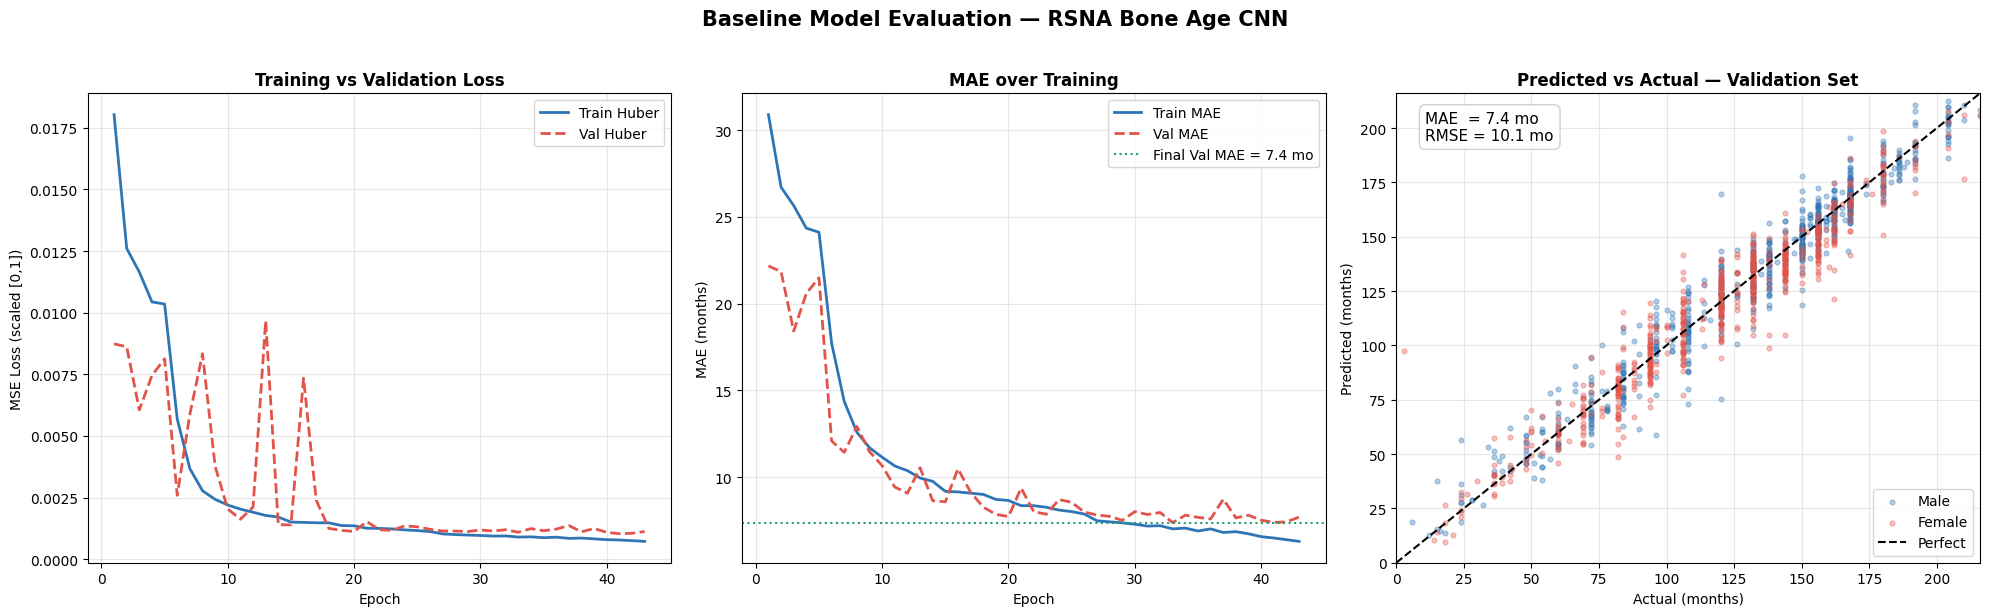

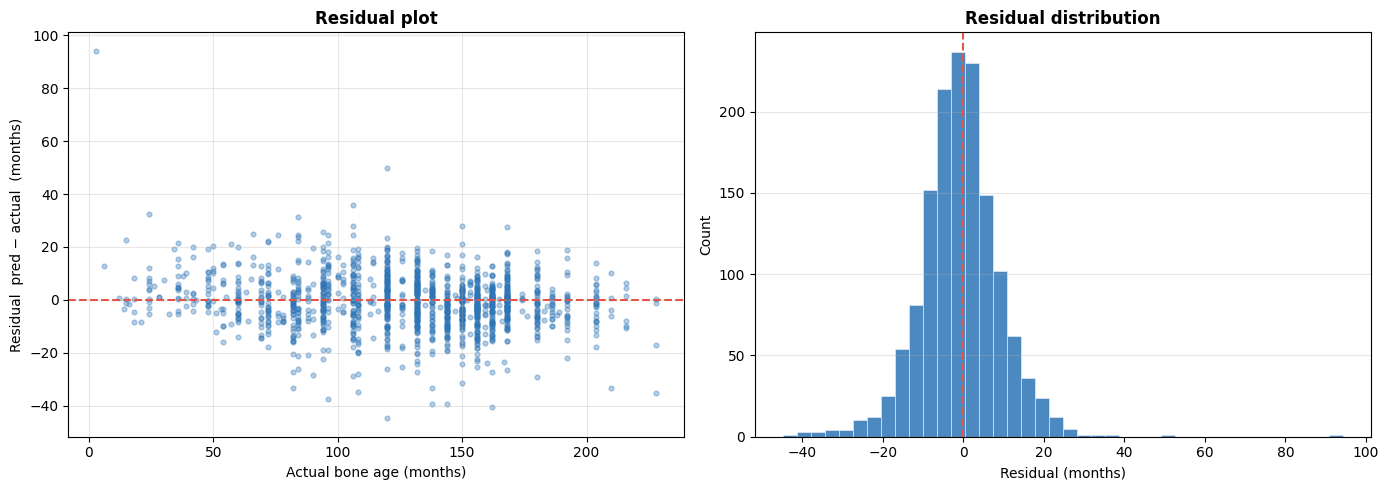

In [10]:
# ============================================================
#  CELL 6 — EVALUATION
#  Uses val_loader (which HAS bone_age labels).
#  test_loader is excluded because gender_test.csv has no
#  bone_age ground truth — evaluation against it is meaningless.
# ============================================================

model.eval()
all_preds, all_labels, all_sexes = [], [], []

with torch.no_grad():
    for imgs, sexes, labels in val_loader:          # ← val_loader (fixed)
        preds = model(imgs.to(DEVICE), sexes.to(DEVICE)).cpu().numpy()
        all_preds.extend(preds          * MAX_AGE)
        all_labels.extend(labels.numpy() * MAX_AGE)
        all_sexes.extend(sexes.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_sexes  = np.array(all_sexes)
residuals  = all_preds - all_labels

# ── Metrics ───────────────────────────────────────────────────
mae  = mean_absolute_error(all_labels, all_preds)
rmse = np.sqrt(np.mean(residuals ** 2))

print("=" * 48)
print("  VALIDATION SET — IMPROVED METRICS")
print("=" * 48)
for sex_val, sex_name in [(1, "Male"), (0, "Female")]:
    mask = all_sexes == sex_val
    if mask.sum() > 0:
        m = mean_absolute_error(all_labels[mask], all_preds[mask])
        r = np.sqrt(np.mean((all_preds[mask] - all_labels[mask])**2))
        print(f"  {sex_name:>6}  MAE = {m:.2f} mo   RMSE = {r:.2f} mo"
              f"   (n={mask.sum()})")
print("-" * 48)
print(f"  OVERALL  MAE  = {mae:.2f} months")
print(f"  OVERALL  RMSE = {rmse:.2f} months")
print("=" * 48)

# ── Plots ────────────────────────────────────────────────────
epochs_ran = len(history["train_loss"])
ep_x       = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Loss curves
ax = axes[0]
ax.plot(ep_x, history["train_loss"], label="Train Huber",
        color="#2E75B6", lw=2)
ax.plot(ep_x, history["val_loss"],   label="Val Huber",
        color="#E2534A", lw=2, linestyle="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (scaled [0,1])")
ax.set_title("Training vs Validation Loss", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# MAE curves
ax = axes[1]
ax.plot(ep_x, history["train_mae"], label="Train MAE",
        color="#2E75B6", lw=2)
ax.plot(ep_x, history["val_mae"],   label="Val MAE",
        color="#E2534A", lw=2, linestyle="--")
ax.axhline(mae, color="#1D9E75", lw=1.5, linestyle=":",
           label=f"Final Val MAE = {mae:.1f} mo")
ax.set_xlabel("Epoch"); ax.set_ylabel("MAE (months)")
ax.set_title("MAE over Training", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# Scatter — colour by sex
ax = axes[2]
for sex_val, sex_name, col in [(1,"Male","#2E75B6"), (0,"Female","#E2534A")]:
    mask = all_sexes == sex_val
    ax.scatter(all_labels[mask], all_preds[mask],
               alpha=0.35, s=12, color=col, label=sex_name)
ax.plot([0, MAX_AGE], [0, MAX_AGE], "k--", lw=1.5, label="Perfect")
ax.set_xlabel("Actual (months)"); ax.set_ylabel("Predicted (months)")
ax.set_title("Predicted vs Actual — Validation Set", fontweight="bold")
ax.set_xlim(0, MAX_AGE); ax.set_ylim(0, MAX_AGE)
ax.legend(); ax.grid(alpha=0.3)
ax.text(0.05, 0.90,
        f"MAE  = {mae:.1f} mo\nRMSE = {rmse:.1f} mo",
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#CCCCCC", alpha=0.9))

plt.suptitle("Baseline Model Evaluation — RSNA Bone Age CNN",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Residuals ────────────────────────────────────────────────
fig2, ax2s = plt.subplots(1, 2, figsize=(14, 5))
ax2s[0].scatter(all_labels, residuals, alpha=0.35, s=12, color="#2E75B6")
ax2s[0].axhline(0, color="#E2534A", lw=1.5, linestyle="--")
ax2s[0].set_xlabel("Actual bone age (months)")
ax2s[0].set_ylabel("Residual  pred − actual  (months)")
ax2s[0].set_title("Residual plot", fontweight="bold")
ax2s[0].grid(alpha=0.3)

ax2s[1].hist(residuals, bins=40, color="#2E75B6",
             edgecolor="white", linewidth=0.4, alpha=0.85)
ax2s[1].axvline(0, color="#E2534A", lw=1.5, linestyle="--")
ax2s[1].set_xlabel("Residual (months)")
ax2s[1].set_ylabel("Count")
ax2s[1].set_title("Residual distribution", fontweight="bold")
ax2s[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("residuals.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# ============================================================
#  CELL 7 — INFERENCE & CHECKPOINT SAVE
#  Demo samples from val_df (has bone_age labels) so that
#  Actual vs Predicted comparison is possible.
#  test_df is used for pure inference (no error column).
# ============================================================

def predict_bone_age(image_path, sex_male: bool,
                     model=model, device=DEVICE):
    """
    Predict bone age in months for a single hand X-ray.
    Parameters
    ----------
    image_path : str | Path
    sex_male   : bool  (True = male, False = female)
    Returns
    -------
    float — predicted bone age in months
    """
    model.eval()
    img    = Image.open(image_path).convert("L")
    tensor = eval_transforms(img).unsqueeze(0).to(device)
    sex    = torch.tensor([float(sex_male)]).to(device)
    with torch.no_grad():
        pred_scaled = model(tensor, sex).item()
    return round(pred_scaled * MAX_AGE, 1)


# ── Demo: val_df  (labeled — shows actual vs predicted) ──────
print("=" * 60)
print("  INFERENCE DEMO — Validation samples (labeled)")
print("=" * 60)
print(f"{'ID':>12} | {'Sex':>7} | {'Actual':>9} | {'Pred':>9} | {'Error':>9}")
print("-" * 60)

for _, row in val_df.sample(5, random_state=SEED).iterrows():  # ← val_df (fixed)
    pred = predict_bone_age(row["path"], bool(row["sex"]))
    err  = pred - row["bone_age"]
    sx   = "Male" if row["sex"] else "Female"
    print(f"{str(row['id']):>12} | {sx:>7} | "
          f"{row['bone_age']:>7.1f} mo | {pred:>7.1f} mo | {err:>+8.1f} mo")

# ── Demo: test_df  (unlabeled — predictions only) ────────────
print()
print("=" * 60)
print("  INFERENCE DEMO — Test samples (no labels)")
print("=" * 60)
print(f"{'ID':>12} | {'Sex':>7} | {'Predicted':>12}")
print("-" * 60)

for _, row in test_df.sample(5, random_state=SEED).iterrows():
    pred = predict_bone_age(row["path"], bool(row["sex"]))
    sx   = "Male" if row["sex"] else "Female"
    print(f"{str(row['id']):>12} | {sx:>7} | {pred:>10.1f} mo")

# ── Save full checkpoint ──────────────────────────────────────
checkpoint = {
    "model_state_dict" : model.state_dict(),
    "config": {
        "img_size"     : IMG_SIZE,
        "max_age"      : MAX_AGE,
        "dropout"      : None,        # baseline has no dropout
        "best_val_mae" : best_val_mae,
        "model_type"   : "baseline_no_regularisation",
    },
    "history": history,
}
torch.save(checkpoint, "bone_age_checkpoint.pth")

print(f"\nSaved:")
print(f"  best_bone_age_model.pth  — best weights by val MAE")
print(f"  bone_age_checkpoint.pth  — full checkpoint + history")
print(f"\nTo reload:")
print("""
  ckpt  = torch.load('bone_age_checkpoint.pth', map_location='cpu')
  model = BoneAgeCNN().to(DEVICE)
  model.load_state_dict(ckpt['model_state_dict'])
  model.eval()
""")


  INFERENCE DEMO — Validation samples (labeled)
          ID |     Sex |    Actual |      Pred |     Error
------------------------------------------------------------
        7985 |  Female |    82.0 mo |    81.1 mo |     -0.9 mo
        8534 |  Female |   156.0 mo |   133.6 mo |    -22.4 mo
       12368 |  Female |   162.0 mo |   134.6 mo |    -27.4 mo
        7513 |  Female |   132.0 mo |   137.8 mo |     +5.8 mo
       11600 |  Female |    94.0 mo |   113.9 mo |    +19.9 mo

  INFERENCE DEMO — Test samples (no labels)
          ID |     Sex |    Predicted
------------------------------------------------------------
        4455 |    Male |       41.1 mo
        4375 |    Male |      144.3 mo
        4390 |    Male |      160.0 mo
        4518 |  Female |      118.2 mo
        4488 |  Female |      151.2 mo

Saved:
  best_bone_age_model.pth  — best weights by val MAE
  bone_age_checkpoint.pth  — full checkpoint + history

To reload:

  ckpt  = torch.load('bone_age_checkpoint.pth', m